# Climatology Analysis: Köppen-Geiger Climate Classification for the Iberian Peninsula (2020-2025)

This notebook demonstrates how to load the high-resolution vector boundary of the Iberian Peninsula, load the aggregated ERA5-Land monthly temperature and precipitation climatology (2020-2025), perform 10x spatial spline interpolation to refine the resolution, run a vectorized Köppen-Geiger classification algorithm, and render a publication-ready climate zone map.

### Key Technical Workflow:
1. **Vector Masking**: Load the high-resolution vector boundary from `sidsgeopackages/iberian_peninsula_highres.gpkg`. This shape represents the Iberian Peninsula mainland.
2. **Climate Climatology**: Load `iberian_peninsula_era5_monthly.nc` containing the 6-year aggregated monthly temperature and precipitation sums at 0.25° resolution.
3. **10x Spline Interpolation**: Interpolate the continuous temperature and precipitation variables 10x using `xarray` cubic splines (down to 0.025° resolution, ~2.5 km spacing).
4. **Vectorized Classification**: Run the Köppen-Geiger classification algorithm on the high-resolution temperature and precipitation grids, ensuring that the boundaries between zones are physically consistent.
5. **Ocean Masking**: Mask out the ocean using `shapely.contains_xy` on the high-resolution coordinate mesh, styling ocean cells in a soft blue color.
6. **Discrete Visualization**: Render the final map using the official Köppen-Geiger color palette and descriptions.

In [1]:
# Import dependencies
import xarray as xr
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
from shapely import contains_xy

print("All libraries imported successfully!")

All libraries imported successfully!


## Section 1: Loading Boundaries and Climate Data

In [2]:
# Load vector boundary
gpkg_path = 'sidsgeopackages/iberian_peninsula_highres.gpkg'
gdf = gpd.read_file(gpkg_path)
mainland_geom = gdf.geometry.iloc[0]
print("--- Vector Boundary Schema ---")
print(gdf)

# Load NetCDF climatology (0.25 degree resolution)
nc_path = 'iberian_peninsula_era5_monthly.nc'
ds = xr.open_dataset(nc_path)
print("\n--- Climate NetCDF Structure ---")
print(ds)

--- Vector Boundary Schema ---
                         name  \
0  Iberian Peninsula Mainland   

                                        display_name  \
0  Iberian Peninsula Mainland (Spain, Portugal, A...   

                                            geometry  
0  POLYGON ((-5.35839 36.14111, -5.36661 36.16315...  


d:\antigravity\Coastcomparedfinalpaper\.venv\Lib\site-packages\xarray\backends\plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
d:\antigravity\Coastcomparedfinalpaper\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- Climate NetCDF Structure ---
<xarray.Dataset> Size: 330kB
Dimensions:    (latitude: 33, longitude: 52, month: 12)
Coordinates:
  * latitude   (latitude) float64 264B 36.0 36.25 36.5 36.75 ... 43.5 43.75 44.0
  * longitude  (longitude) float64 416B -9.5 -9.25 -9.0 -8.75 ... 2.75 3.0 3.25
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    temp       (latitude, longitude, month) float64 165kB ...
    precip     (latitude, longitude, month) float64 165kB ...
Attributes:
    description:  Monthly climatology NASA POWER (2020-2025) for the Iberian ...
    resolution:   0.25 degree


## Section 2: 10x Cubic Spline Interpolation

We interpolate the monthly temperature and precipitation climatology 10x to smooth the contours before classification. This yields a 330x520 grid (0.025° resolution).

In [3]:
lats = ds['latitude'].values
lons = ds['longitude'].values

# Set up 10x finer coordinates
new_lats = np.linspace(lats.min(), lats.max(), len(lats) * 10)
new_lons = np.linspace(lons.min(), lons.max(), len(lons) * 10)
grid_x, grid_y = np.meshgrid(new_lons, new_lats)

print(f"Raw grid dimensions: {len(lats)}x{len(lons)}")
print(f"Interpolated grid dimensions: {grid_x.shape[0]}x{grid_x.shape[1]}")

# Fill land-mask NaNs along spatial dimensions using ffill/bfill to enable cubic interpolation
print("Filling NaNs to prepare for interpolation...")
ds_filled = ds.ffill(dim='longitude').bfill(dim='longitude').ffill(dim='latitude').bfill(dim='latitude')

# Interpolate temp and precip using xarray's cubic spline method
print("Running xarray 10x cubic spline interpolation...")
ds_interp = ds_filled.interp(latitude=new_lats, longitude=new_lons, method='cubic')

Raw grid dimensions: 33x52
Interpolated grid dimensions: 330x520
Filling NaNs to prepare for interpolation...
Running xarray 10x cubic spline interpolation...


## Section 3: Vectorized Köppen-Geiger Classifier

We define the standard mathematical criteria of Peel et al. (2007) and Beck et al. (2018) in a fully vectorized numpy function.

In [4]:
def classify_koppen_vectorized(temp, precip):
    # temp: shape (12, lat, lon)
    # precip: shape (12, lat, lon)
    # returns: integer grid of shape (lat, lon)
    
    # Calculate yearly aggregates
    t_ann = temp.mean(axis=0)
    p_ann = precip.sum(axis=0)
    t_min = temp.min(axis=0)
    t_max = temp.max(axis=0)
    
    # Count of months with temp >= 10
    t_ge_10 = (temp >= 10.0).sum(axis=0)
    
    # Summer/winter half precipitation sums (Northern Hemisphere)
    # Summer half: Apr, May, Jun, Jul, Aug, Sep (indices 3 to 8)
    p_summer = precip[3:9].sum(axis=0)
    # Winter half: Jan, Feb, Mar, Oct, Nov, Dec (indices 0,1,2, 9,10,11)
    p_winter = precip[[9, 10, 11, 0, 1, 2]].sum(axis=0)
    
    # Monthly min/max precip in summer/winter halves
    p_sdry = precip[3:9].min(axis=0)
    p_swet = precip[3:9].max(axis=0)
    p_wdry = precip[[9, 10, 11, 0, 1, 2]].min(axis=0)
    p_wwet = precip[[9, 10, 11, 0, 1, 2]].max(axis=0)
    
    # Dryness threshold P_threshold (in mm)
    p_thresh = np.zeros_like(t_ann)
    mask_summer = p_summer >= 0.7 * p_ann
    mask_winter = p_winter >= 0.7 * p_ann
    mask_even = ~(mask_summer | mask_winter)
    
    p_thresh[mask_summer] = 20.0 * t_ann[mask_summer] + 280.0
    p_thresh[mask_winter] = 20.0 * t_ann[mask_winter]
    p_thresh[mask_even] = 20.0 * t_ann[mask_even] + 140.0
    
    p_thresh = np.maximum(p_thresh, 0)
    
    # Group B: Arid
    is_B = p_ann < p_thresh
    is_BW = is_B & (p_ann < 0.5 * p_thresh)
    is_BS = is_B & ~is_BW
    
    # Group E: Polar
    is_E = ~is_B & (t_max < 10.0)
    is_ET = is_E & (t_max >= 0.0)
    is_EF = is_E & (t_max < 0.0)
    
    # Group A: Tropical
    is_A = ~is_B & ~is_E & (t_min >= 18.0)
    p_min = precip.min(axis=0)
    is_Af = is_A & (p_min >= 60.0)
    is_Am = is_A & ~is_Af & (p_min >= (100.0 - p_ann / 25.0))
    is_Aw = is_A & ~is_Af & ~is_Am
    
    # Group C: Temperate
    is_C = ~is_B & ~is_E & ~is_A & (t_min > -3.0) & (t_min < 18.0)
    
    # Group D: Continental
    is_D = ~is_B & ~is_E & ~is_A & ~is_C
    
    # Seasonality for C and D
    s_season = (p_sdry < 40.0) & (p_sdry < p_wwet / 3.0)
    w_season = ~s_season & (p_wdry < p_swet / 10.0)
    f_season = ~s_season & ~w_season
    
    # Summer temperature types
    a_temp = t_max >= 22.0
    b_temp = ~a_temp & (t_ge_10 >= 4)
    c_temp = ~a_temp & ~b_temp & (t_min > -38.0)
    d_temp = ~a_temp & ~b_temp & ~c_temp
    
    koppen = np.zeros_like(t_ann, dtype=int)
    
    # Group A
    koppen[is_Af] = 1
    koppen[is_Am] = 2
    koppen[is_Aw] = 3
    
    # Group B
    koppen[is_BW & (t_ann >= 18.0)] = 4  # BWh
    koppen[is_BW & (t_ann < 18.0)] = 5   # BWk
    koppen[is_BS & (t_ann >= 18.0)] = 6  # BSh
    koppen[is_BS & (t_ann < 18.0)] = 7   # BSk
    
    # Group C
    koppen[is_C & s_season & a_temp] = 8   # Csa
    koppen[is_C & s_season & b_temp] = 9   # Csb
    koppen[is_C & s_season & c_temp] = 10  # Csc
    koppen[is_C & w_season & a_temp] = 11  # Cwa
    koppen[is_C & w_season & b_temp] = 12  # Cwb
    koppen[is_C & w_season & c_temp] = 13  # Cwc
    koppen[is_C & f_season & a_temp] = 14  # Cfa
    koppen[is_C & f_season & b_temp] = 15  # Cfb
    koppen[is_C & f_season & c_temp] = 16  # Cfc
    
    # Group D
    koppen[is_D & s_season & a_temp] = 17  # Dsa
    koppen[is_D & s_season & b_temp] = 18  # Dsb
    koppen[is_D & s_season & c_temp] = 19  # Dsc
    koppen[is_D & s_season & d_temp] = 20  # Dsd
    koppen[is_D & w_season & a_temp] = 21  # Dwa
    koppen[is_D & w_season & b_temp] = 22  # Dwb
    koppen[is_D & w_season & c_temp] = 23  # Dwc
    koppen[is_D & w_season & d_temp] = 24  # Dwd
    koppen[is_D & f_season & a_temp] = 25  # Dfa
    koppen[is_D & f_season & b_temp] = 26  # Dfb
    koppen[is_D & f_season & c_temp] = 27  # Dfc
    koppen[is_D & f_season & d_temp] = 28  # Dfd
    
    # Group E
    koppen[is_ET] = 29  # ET
    koppen[is_EF] = 30  # EF
    
    return koppen

## Section 4: Applying Masking and Classifying

We use `shapely.contains_xy` to build a high-resolution boolean mask of the land. We extract the interpolated temperature and precipitation values, mask them, run the classifier, and mask out the ocean cells.

In [5]:
print("Generating high-resolution land mask...")
# Create boolean mask for the mainland
mask = contains_xy(mainland_geom, grid_x, grid_y)
print(f"Land mask has {mask.sum()} elements out of {mask.size} total cells.")

# Extract temperature and precipitation from interpolated xarray Dataset
t_interp = ds_interp['temp'].transpose('month', 'latitude', 'longitude').values  # Shape: (12, lat, lon)
p_interp = ds_interp['precip'].transpose('month', 'latitude', 'longitude').values

# Run vectorized classifier
print("Running climate classification...")
koppen_grid = classify_koppen_vectorized(t_interp, p_interp)

# Mask out ocean cells (set to 0)
koppen_grid[~mask] = 0

present_codes = np.unique(koppen_grid)
print("Present climate codes in the grid:", [c for c in present_codes if c != 0])

Generating high-resolution land mask...
Land mask has 103356 elements out of 171600 total cells.
Running climate classification...
Present climate codes in the grid: [np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(14)]


## Section 5: Mapping the Climate Zones

We plot the discrete climate zones using the official colors and names.

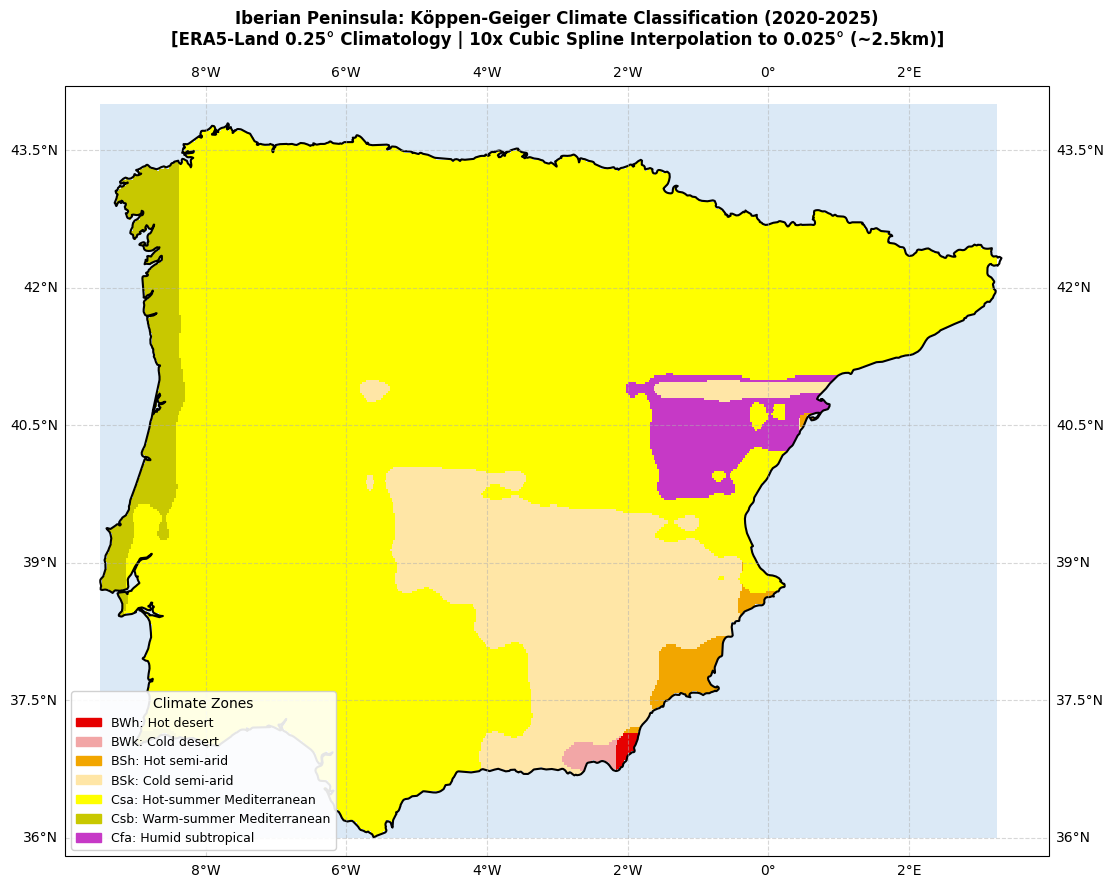

In [6]:
koppen_info = {
    1: ('Af', '#0000ff'), 2: ('Am', '#00a0ff'), 3: ('Aw', '#41c8ff'),
    4: ('BWh', '#e60000'), 5: ('BWk', '#f2a6a6'), 6: ('BSh', '#f2a600'), 7: ('BSk', '#ffe6a6'),
    8: ('Csa', '#ffff00'), 9: ('Csb', '#c8c800'), 10: ('Csc', '#969600'),
    11: ('Cwa', '#e6a6ff'), 12: ('Cwb', '#c672ff'), 13: ('Cwc', '#9639ff'),
    14: ('Cfa', '#c639c6'), 15: ('Cfb', '#00e600'), 16: ('Cfc', '#00a600'),
    17: ('Dsa', '#f23eff'), 18: ('Dsb', '#c639ff'), 19: ('Dsc', '#9600c6'), 20: ('Dsd', '#6e0099'),
    21: ('Dwa', '#abffa6'), 22: ('Dwb', '#72e66d'), 23: ('Dwc', '#39c639'), 24: ('Dwd', '#009600'),
    25: ('Dfa', '#33ffea'), 26: ('Dfb', '#38c6ff'), 27: ('Dfc', '#0072ff'), 28: ('Dfd', '#0000e6'),
    29: ('ET', '#b2b2b2'), 30: ('EF', '#666666')
}

name_full = {
    'Af': 'Tropical rainforest', 'Am': 'Tropical monsoon', 'Aw': 'Tropical savanna',
    'BWh': 'Hot desert', 'BWk': 'Cold desert', 'BSh': 'Hot semi-arid', 'BSk': 'Cold semi-arid',
    'Csa': 'Hot-summer Mediterranean', 'Csb': 'Warm-summer Mediterranean', 'Csc': 'Cold-summer Mediterranean',
    'Cwa': 'Humid subtropical winter-dry', 'Cwb': 'Subtropical highland winter-dry', 'Cwc': 'Subpolar highland winter-dry',
    'Cfa': 'Humid subtropical', 'Cfb': 'Temperate oceanic', 'Cfc': 'Subpolar oceanic',
    'Dsa': 'Humid continental dry-summer hot-summer', 'Dsb': 'Humid continental dry-summer warm-summer', 'Dsc': 'Subarctic dry-summer', 'Dsd': 'Subarctic dry-summer extremely cold',
    'Dwa': 'Humid continental winter-dry hot-summer', 'Dwb': 'Humid continental winter-dry warm-summer', 'Dwc': 'Subarctic winter-dry', 'Dwd': 'Subarctic winter-dry extremely cold',
    'Dfa': 'Humid continental hot-summer', 'Dfb': 'Humid continental warm-summer', 'Dfc': 'Subarctic cool-summer', 'Dfd': 'Subarctic extremely cold',
    'ET': 'Tundra (Alpine)', 'EF': 'Ice cap'
}

# Map present codes to consecutive indices for ListedColormap
present_codes = sorted([c for c in np.unique(koppen_grid) if c != 0])
grid_mapped = np.zeros_like(koppen_grid)

# Colormap list starts with ocean color at index 0
colors_list = ['#dbe9f6']
patches = []

for idx, code in enumerate(present_codes, 1):
    grid_mapped[koppen_grid == code] = idx
    name, color = koppen_info[code]
    colors_list.append(color)
    patches.append(mpatches.Patch(color=color, label=f"{name}: {name_full[name]}"))

cmap = mcolors.ListedColormap(colors_list)
bounds = np.arange(len(colors_list) + 1) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Plot map
fig, ax = plt.subplots(figsize=(14, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-10.0, 4.0, 35.8, 44.2], crs=ccrs.PlateCarree())

im = ax.imshow(grid_mapped, extent=[-9.5, 3.25, 36.0, 44.0], origin='lower',
               cmap=cmap, norm=norm, interpolation='nearest', zorder=1)

# Add vector boundaries
gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5, zorder=2)

# Titles and Gridlines
ax.set_title("Iberian Peninsula: Köppen-Geiger Climate Classification (2020-2025)\n[ERA5-Land 0.25° Climatology | 10x Cubic Spline Interpolation to 0.025° (~2.5km)]", 
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

# Legend
ax.legend(handles=patches, title="Climate Zones", loc='lower left', framealpha=0.9, fontsize=9)
plt.savefig("iberian_koppen_geiger_map.png", dpi=150, bbox_inches='tight')
plt.show()

## Section 6: Statistical Distribution of Climate Zones

We calculate the area percentage of each climate zone on the mainland.

In [ ]:
land_cell_count = mask.sum()
stats_list = []
for code in present_codes:
    name, _ = koppen_info[code]
    count = (koppen_grid == code).sum()
    pct = (count / land_cell_count) * 100
    stats_list.append({
        "Code": name,
        "Description": name_full[name],
        "Cell Count": count,
        "Area Percentage (%)": round(pct, 2)
    })
    
df_stats = pd.DataFrame(stats_list).sort_values(by="Area Percentage (%)", ascending=False)
print("\n--- Climate Zone Distribution Table ---")
display(df_stats)


--- Climate Zone Distribution Table ---


,Code,Description,Cell Count,Area Percentage (%)
4,Csa,Hot-summer Mediterranean,78703,76.15
3,BSk,Cold semi-arid,16329,15.80
5,Csb,Warm-summer Mediterranean,3645,3.53
6,Cfa,Humid subtropical,3273,3.17
2,BSh,Hot semi-arid,980,0.95
1,BWk,Cold desert,296,0.29
0,BWh,Hot desert,130,0.13


: 